# Doprinos 5 — Analiza uticaja kvantizacije na latenciju, RAM i Real-Time Factor Faster-Whisper modela

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja kvantizacije na performanse Faster-Whisper modela pri izvršavanju na CPU-u. Direktno se porede `INT8` i `FLOAT32` konfiguracije modela `tiny`, `base`, `small` i `medium`.

Eksperiment koristi svih **40 prirodnih srpskih audio zapisa**, tako da je ukupno izvršeno **320 merenih transkripcija** za analizu vremena obrade i RTF-a. Za svaku konfiguraciju analiziraju se prosečno vreme obrade, Real-Time Factor (RTF), vreme učitavanja modela i memorijska zahtevnost.

Glavni cilj je utvrditi koliko INT8 kvantizacija može ubrzati izvršavanje i smanjiti računarski zahtev u odnosu na FLOAT32, kao i kako efekat kvantizacije zavisi od veličine modela.

---

## Metodologija merenja

Za merenje vremena obrade i RTF-a zadržana je postojeća procedura: za svaku kombinaciju modela i kvantizacije model se učitava jednom, nakon čega se izvršava nemereno warm-up prepoznavanje. Svih 40 snimaka zatim se obrađuje istim parametrima dekodiranja (`beam_size=1`, `temperature=0.0`, bez VAD filtriranja). Vreme učitavanja modela ne uključuje se u vreme transkripcije.

RTF se računa kao odnos vremena obrade i trajanja audio zapisa. Vrednost `RTF < 1` znači da se audio obrađuje brže od njegovog realnog trajanja.

**RAM se za konačno poređenje konfiguracija meri odvojeno od glavne Jupyter petlje.** Svaka od osam konfiguracija (`tiny`, `base`, `small`, `medium` × `INT8`, `FLOAT32`) pokreće se u **zasebnom Python procesu**, čime se sprečava da prethodno učitani modeli, keš i alokacije memorije utiču na sledeće merenje. Za svaku konfiguraciju izvode se **tri nezavisna ponavljanja**. U svakom procesu prati se RSS memorija od neposredno pre učitavanja modela, preko učitavanja i jedne kontrolisane transkripcije istog najdužeg audio zapisa. Kao glavna memorijska metrika koristi se **peak RSS**, a za svaku konfiguraciju prikazuju se srednja vrednost i standardna devijacija. Dodatno se čuva i porast peak RSS-a u odnosu na početni RSS procesa.

RSS vrednosti koje se i dalje beleže tokom 320 glavnih transkripcija služe samo kao dijagnostički podaci i **ne koriste se za konačno rangiranje konfiguracija**.


In [1]:
from pathlib import Path
import os
import gc
import time
import wave
import threading
import subprocess
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

from faster_whisper import WhisperModel

In [2]:
# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "05_kvantizacija_latencija_rtf"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\05_kvantizacija_latencija_rtf


In [3]:
# ============================================================
# DEFINISANJE SVIH 40 PRIRODNIH SRPSKIH SNIMAKA
# ============================================================

govornik1_brojevi = set(
    list(range(1, 5)) +
    list(range(11, 16)) +
    list(range(26, 29)) +
    [36]
)

govornik2_brojevi = set(
    list(range(5, 8)) +
    list(range(16, 21)) +
    list(range(29, 32)) +
    [37, 38]
)

govornik3_brojevi = set(
    list(range(8, 11)) +
    list(range(21, 26)) +
    list(range(32, 36)) +
    [39, 40]
)


def odredi_govornika(broj):
    if broj in govornik1_brojevi:
        return "govornik1"
    if broj in govornik2_brojevi:
        return "govornik2"
    if broj in govornik3_brojevi:
        return "govornik3"
    raise ValueError(f"Nepoznat govornik za audio broj {broj}")


def odredi_grupu_duzine(broj):
    if 1 <= broj <= 10:
        return "kratki"
    elif 11 <= broj <= 25:
        return "srednji"
    elif 26 <= broj <= 35:
        return "dugi"
    elif 36 <= broj <= 40:
        return "veoma_dugi"
    else:
        raise ValueError(f"Nepoznata grupa za audio broj {broj}")


test_set = []

for broj in range(1, 41):
    govornik = odredi_govornika(broj)
    grupa = odredi_grupu_duzine(broj)

    fajl = AUDIO_DIR / f"{broj}{govornik}.wav"

    test_set.append({
        "broj": broj,
        "audio": fajl,
        "govornik": govornik,
        "grupa": grupa
    })


for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(
            f"Audio fajl nije pronađen: {item['audio']}"
        )

print(f"Sva {len(test_set)} audio fajla su pronađena.")

print("\nBroj fajlova po govorniku:")
print(pd.Series([x["govornik"] for x in test_set]).value_counts())

print("\nBroj fajlova po grupi dužine:")
print(pd.Series([x["grupa"] for x in test_set]).value_counts())

Sva 40 audio fajla su pronađena.

Broj fajlova po govorniku:
govornik3    14
govornik1    13
govornik2    13
Name: count, dtype: int64

Broj fajlova po grupi dužine:
srednji       15
kratki        10
dugi          10
veoma_dugi     5
Name: count, dtype: int64


In [4]:
# ============================================================
# POMOĆNE FUNKCIJE
# ============================================================

def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as wf:
        frames = wf.getnframes()
        rate = wf.getframerate()
        return frames / float(rate)


process = psutil.Process(os.getpid())


def trenutni_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def transkribuj_i_izmeri(model, putanja):
    """
    Meri ukupno vreme obrade i procesni peak RSS tokom transkripcije.

    RAM delta predstavlja povećanje procesnog RSS-a iznad vrednosti
    neposredno pre početka transkripcije.
    """

    ram_pre = trenutni_ram_mb()

    memorija_uzorci = [ram_pre]
    stop_event = threading.Event()

    def monitor_memorije():
        while not stop_event.is_set():
            memorija_uzorci.append(trenutni_ram_mb())
            time.sleep(0.02)

        memorija_uzorci.append(trenutni_ram_mb())

    monitor_thread = threading.Thread(
        target=monitor_memorije,
        daemon=True
    )

    monitor_thread.start()

    start = time.perf_counter()

    try:
        segments, info = model.transcribe(
            str(putanja),
            language="sr",
            beam_size=1,
            temperature=0.0,
            vad_filter=False
        )

        transkript = " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

    finally:
        vreme = time.perf_counter() - start

        stop_event.set()
        monitor_thread.join()

    peak_ram = max(memorija_uzorci)
    dodatni_ram = max(0.0, peak_ram - ram_pre)

    return {
        "transkript": transkript,
        "vreme": vreme,
        "ram_pre": ram_pre,
        "peak_ram": peak_ram,
        "dodatni_ram": dodatni_ram
    }

In [5]:
# ============================================================
# KONFIGURACIJE EKSPERIMENTA
# ============================================================

model_velicine = [
    "tiny",
    "base",
    "small",
    "medium"
]

kvantizacije = [
    "int8",
    "float32"
]

uredjaj = "cpu"

print("Modeli:", model_velicine)
print("Kvantizacije:", kvantizacije)
print("Uređaj:", uredjaj)
print(
    "Ukupan broj merenih transkripcija:",
    len(model_velicine) * len(kvantizacije) * len(test_set)
)

Modeli: ['tiny', 'base', 'small', 'medium']
Kvantizacije: ['int8', 'float32']
Uređaj: cpu
Ukupan broj merenih transkripcija: 320


In [6]:
# ============================================================
# GLAVNI EKSPERIMENT
# ============================================================

rezultati = []
model_load_rezultati = []


for model_size in model_velicine:

    for compute_type in kvantizacije:

        print("\n" + "=" * 100)
        print(
            f"MODEL = {model_size.upper()} | "
            f"KVANTIZACIJA = {compute_type.upper()} | CPU"
        )
        print("=" * 100)


        gc.collect()
        time.sleep(0.5)

        ram_pre_ucitavanja = trenutni_ram_mb()

        start_load = time.perf_counter()

        try:
            model = WhisperModel(
                model_size,
                device="cpu",
                compute_type=compute_type
            )

        except Exception as e:
            print(
                f"Greška pri učitavanju {model_size} / "
                f"{compute_type}: {e}"
            )
            continue


        load_time = time.perf_counter() - start_load

        ram_nakon_ucitavanja = trenutni_ram_mb()
        ram_delta_model = max(
            0.0,
            ram_nakon_ucitavanja - ram_pre_ucitavanja
        )


        print(f"Vreme učitavanja modela: {load_time:.2f} s")
        print(f"RSS pre učitavanja: {ram_pre_ucitavanja:.2f} MB")
        print(f"RSS nakon učitavanja: {ram_nakon_ucitavanja:.2f} MB")
        print(f"Promena RSS-a pri učitavanju: {ram_delta_model:.2f} MB")


        model_load_rezultati.append({
            "Model": model_size,
            "Kvantizacija": compute_type,
            "Uređaj": "cpu",
            "Model Load Time [s]": round(load_time, 3),
            "RSS pre učitavanja [MB]": round(ram_pre_ucitavanja, 2),
            "RSS nakon učitavanja [MB]": round(ram_nakon_ucitavanja, 2),
            "RAM delta učitavanja [MB]": round(ram_delta_model, 2)
        })


        # --------------------------------------------------------
        # WARM-UP — NE ULAZI U REZULTATE
        # --------------------------------------------------------

        print("Warm-up...")

        try:
            segments, _ = model.transcribe(
                str(test_set[0]["audio"]),
                language="sr",
                beam_size=1,
                temperature=0.0,
                vad_filter=False
            )

            _ = " ".join(
                segment.text.strip()
                for segment in segments
            )

        except Exception as e:
            print("Warm-up greška:", e)


        print("Počinje merenje 40 audio zapisa...\n")


        for indeks, item in enumerate(test_set, start=1):

            audio_trajanje = trajanje_wav(item["audio"])

            try:
                merenje = transkribuj_i_izmeri(
                    model,
                    item["audio"]
                )

            except Exception as e:
                print(
                    f"GREŠKA {item['audio'].name}: {e}"
                )
                continue


            latency = merenje["vreme"]

            rtf = (
                latency / audio_trajanje
                if audio_trajanje > 0
                else np.nan
            )


            rezultati.append({
                "Model": model_size,
                "Kvantizacija": compute_type,
                "Uređaj": "cpu",
                "Broj": item["broj"],
                "Audio": item["audio"].name,
                "Govornik": item["govornik"],
                "Grupa_duzine": item["grupa"],
                "Audio Trajanje [s]": round(audio_trajanje, 3),
                "Vreme obrade [s]": round(latency, 3),
                "RTF": round(rtf, 4),
                "Brže od realnog vremena": bool(rtf < 1.0),
                "RSS pre transkripcije [MB]": round(merenje["ram_pre"], 2),
                "Peak RSS [MB]": round(merenje["peak_ram"], 2),
                "Dodatni peak RAM [MB]": round(merenje["dodatni_ram"], 2),
                "Model Load Time [s]": round(load_time, 3),
                "Transkript": merenje["transkript"]
            })


            print(
                f"[{indeks:02d}/40] "
                f"{item['audio'].name:<20} | "
                f"{audio_trajanje:7.2f} s audio | "
                f"{latency:7.2f} s obrada | "
                f"RTF {rtf:6.3f} | "
                f"RAM +{merenje['dodatni_ram']:7.2f} MB"
            )


        del model
        gc.collect()
        time.sleep(1.0)


print("\nEksperiment je završen.")
print(f"Broj uspešnih merenja: {len(rezultati)}")


MODEL = TINY | KVANTIZACIJA = INT8 | CPU
Vreme učitavanja modela: 0.91 s
RSS pre učitavanja: 287.57 MB
RSS nakon učitavanja: 361.42 MB
Promena RSS-a pri učitavanju: 73.85 MB
Warm-up...
Počinje merenje 40 audio zapisa...

[01/40] 1govornik1.wav       |    7.60 s audio |    0.84 s obrada | RTF  0.111 | RAM + 117.57 MB
[02/40] 2govornik1.wav       |    6.78 s audio |    0.79 s obrada | RTF  0.116 | RAM + 116.27 MB
[03/40] 3govornik1.wav       |    5.83 s audio |    0.73 s obrada | RTF  0.125 | RAM + 116.70 MB
[04/40] 4govornik1.wav       |    7.29 s audio |    0.78 s obrada | RTF  0.106 | RAM + 116.60 MB
[05/40] 5govornik2.wav       |    9.33 s audio |    0.87 s obrada | RTF  0.093 | RAM + 116.42 MB
[06/40] 6govornik2.wav       |    7.89 s audio |    0.83 s obrada | RTF  0.105 | RAM + 116.23 MB
[07/40] 7govornik2.wav       |    8.73 s audio |    0.77 s obrada | RTF  0.088 | RAM + 116.19 MB
[08/40] 8govornik3.wav       |    5.21 s audio |    0.77 s obrada | RTF  0.147 | RAM + 102.96 MB
[0

In [7]:
# ============================================================
# DETALJNI REZULTATI
# ============================================================

tabela_rezultati = pd.DataFrame(rezultati)
tabela_model_load = pd.DataFrame(model_load_rezultati)

display(
    tabela_rezultati[
        [
            "Model",
            "Kvantizacija",
            "Broj",
            "Audio",
            "Govornik",
            "Grupa_duzine",
            "Audio Trajanje [s]",
            "Vreme obrade [s]",
            "RTF",
            "Dodatni peak RAM [MB]"
        ]
    ]
)

,Model,Kvantizacija,Broj,Audio,Govornik,Grupa_duzine,Audio Trajanje [s],Vreme obrade [s],RTF,Dodatni peak RAM [MB]
0,tiny,int8,1,1govornik1.wav,govornik1,kratki,7.605,0.843,0.1109,117.57
1,tiny,int8,2,2govornik1.wav,govornik1,kratki,6.780,0.789,0.1164,116.27
2,tiny,int8,3,3govornik1.wav,govornik1,kratki,5.828,0.729,0.1251,116.70
3,tiny,int8,4,4govornik1.wav,govornik1,kratki,7.291,0.776,0.1064,116.60
4,tiny,int8,5,5govornik2.wav,govornik2,kratki,9.334,0.869,0.0930,116.42
...,...,...,...,...,...,...,...,...,...,...
315,medium,float32,36,36govornik1.wav,govornik1,veoma_dugi,69.010,91.870,1.3313,359.25
316,medium,float32,37,37govornik2.wav,govornik2,veoma_dugi,82.431,95.767,1.1618,558.23
317,medium,float32,38,38govornik2.wav,govornik2,veoma_dugi,64.459,75.639,1.1734,679.39
318,medium,float32,39,39govornik3.wav,govornik3,veoma_dugi,62.613,77.014,1.2300,603.62


In [8]:
# ============================================================
# POUZDANO RAM MERENJE — ZASEBAN PROCES, 3 PONAVLJANJA
# ============================================================

BROJ_RAM_PONAVLJANJA = 3

# Za svako RAM merenje koristi se isti najduži audio zapis.
# Time je ulaz identičan za svih 8 konfiguracija i sva ponavljanja.
ram_test_item = max(
    test_set,
    key=lambda x: trajanje_wav(x["audio"])
)

RAM_TEST_AUDIO = ram_test_item["audio"]

print("RAM kontrolni audio:", RAM_TEST_AUDIO.name)
print(f"Trajanje: {trajanje_wav(RAM_TEST_AUDIO):.2f} s")
print("Broj nezavisnih ponavljanja po konfiguraciji:", BROJ_RAM_PONAVLJANJA)


# Worker se izvršava kao POTPUNO NOV Python proces.
# On meri RSS od trenutka pre učitavanja modela do završetka transkripcije.
ram_worker_path = REZULTATI_DIR / "_ram_worker_05.py"

ram_worker_code = r"""
import sys
import json
import time
import threading
import os
import psutil

from faster_whisper import WhisperModel


model_size = sys.argv[1]
compute_type = sys.argv[2]
audio_path = sys.argv[3]

process = psutil.Process(os.getpid())

def rss_mb():
    return process.memory_info().rss / (1024 ** 2)


# Početni RSS meri se nakon uvoza biblioteka, ali pre učitavanja modela.
baseline_rss = rss_mb()
uzorci = [baseline_rss]
stop_event = threading.Event()


def monitor_ram():
    while not stop_event.is_set():
        uzorci.append(rss_mb())
        time.sleep(0.01)

    uzorci.append(rss_mb())


monitor = threading.Thread(
    target=monitor_ram,
    daemon=True
)

monitor.start()

start_load = time.perf_counter()

try:
    model = WhisperModel(
        model_size,
        device="cpu",
        compute_type=compute_type
    )

    load_time = time.perf_counter() - start_load
    rss_after_load = rss_mb()

    # Jedna kontrolisana transkripcija istog audio zapisa.
    # Generator mora biti iscrpljen da bi se obrada zaista izvršila.
    start_transcribe = time.perf_counter()

    segments, _ = model.transcribe(
        audio_path,
        language="sr",
        beam_size=1,
        temperature=0.0,
        vad_filter=False
    )

    _ = " ".join(
        segment.text.strip()
        for segment in segments
    )

    transcribe_time = time.perf_counter() - start_transcribe

finally:
    stop_event.set()
    monitor.join()


peak_rss = max(uzorci)

rezultat = {
    "Model": model_size,
    "Kvantizacija": compute_type,
    "Baseline RSS [MB]": baseline_rss,
    "RSS nakon učitavanja [MB]": rss_after_load,
    "Peak RSS [MB]": peak_rss,
    "Peak RSS delta [MB]": max(0.0, peak_rss - baseline_rss),
    "Model Load Time [s]": load_time,
    "Kontrolna transkripcija [s]": transcribe_time
}

print("RAM_RESULT_JSON=" + json.dumps(rezultat))
"""

ram_worker_path.write_text(
    ram_worker_code,
    encoding="utf-8"
)


ram_merenja = []

for model_size in model_velicine:
    for compute_type in kvantizacije:

        print("\n" + "=" * 100)
        print(
            f"RAM: {model_size.upper()} / "
            f"{compute_type.upper()} — "
            f"{BROJ_RAM_PONAVLJANJA} zasebna procesa"
        )
        print("=" * 100)

        for ponavljanje in range(1, BROJ_RAM_PONAVLJANJA + 1):

            komanda = [
                sys.executable,
                str(ram_worker_path),
                model_size,
                compute_type,
                str(RAM_TEST_AUDIO)
            ]

            rezultat_procesa = subprocess.run(
                komanda,
                capture_output=True,
                text=True,
                encoding="utf-8",
                errors="replace"
            )

            if rezultat_procesa.returncode != 0:
                print(
                    f"GREŠKA: {model_size}/{compute_type}, "
                    f"ponavljanje {ponavljanje}"
                )
                print(rezultat_procesa.stderr)
                continue

            json_linija = None

            for linija in rezultat_procesa.stdout.splitlines():
                if linija.startswith("RAM_RESULT_JSON="):
                    json_linija = linija[len("RAM_RESULT_JSON="):]
                    break

            if json_linija is None:
                print(
                    f"GREŠKA: nema RAM rezultata za "
                    f"{model_size}/{compute_type}, "
                    f"ponavljanje {ponavljanje}"
                )
                print(rezultat_procesa.stdout)
                continue

            red = json.loads(json_linija)
            red["Ponavljanje"] = ponavljanje
            red["Kontrolni audio"] = RAM_TEST_AUDIO.name

            ram_merenja.append(red)

            print(
                f"[{ponavljanje}/{BROJ_RAM_PONAVLJANJA}] "
                f"Peak RSS = {red['Peak RSS [MB]']:.2f} MB | "
                f"delta = {red['Peak RSS delta [MB]']:.2f} MB"
            )


tabela_ram_ponavljanja = pd.DataFrame(ram_merenja)

if tabela_ram_ponavljanja.empty:
    raise RuntimeError(
        "Nijedno nezavisno RAM merenje nije uspešno završeno."
    )


# Zahtevamo sva 3 ponavljanja za svaku od 8 konfiguracija.
broj_uspesnih = (
    tabela_ram_ponavljanja
    .groupby(["Model", "Kvantizacija"])
    .size()
)

ocekivane_konfiguracije = len(model_velicine) * len(kvantizacije)

if (
    len(broj_uspesnih) != ocekivane_konfiguracije
    or (broj_uspesnih < BROJ_RAM_PONAVLJANJA).any()
):
    raise RuntimeError(
        "RAM eksperiment nije kompletan: "
        "svaka konfiguracija mora imati sva 3 uspešna ponavljanja."
    )


tabela_ram_rezime = (
    tabela_ram_ponavljanja
    .groupby(["Model", "Kvantizacija"])
    .agg(
        Broj_ponavljanja=("Ponavljanje", "count"),
        Peak_RSS_mean_MB=("Peak RSS [MB]", "mean"),
        Peak_RSS_std_MB=("Peak RSS [MB]", "std"),
        Peak_RSS_min_MB=("Peak RSS [MB]", "min"),
        Peak_RSS_max_MB=("Peak RSS [MB]", "max"),
        Peak_RSS_delta_mean_MB=("Peak RSS delta [MB]", "mean"),
        Peak_RSS_delta_std_MB=("Peak RSS delta [MB]", "std"),
        Baseline_RSS_mean_MB=("Baseline RSS [MB]", "mean")
    )
    .reset_index()
    .round(2)
)


print("\nPOUZDANO RAM MERENJE — PEAK RSS, 3 NEZAVISNA PROCESA")
display(tabela_ram_rezime)

print(
    "\nNAPOMENA: Za rangiranje u notebooku 08 koristiti "
    "'Peak_RSS_mean_MB', a 'Peak_RSS_std_MB' prikazati kao "
    "standardnu devijaciju."
)


RAM kontrolni audio: 37govornik2.wav
Trajanje: 82.43 s
Broj nezavisnih ponavljanja po konfiguraciji: 3

RAM: TINY / INT8 — 3 zasebna procesa
[1/3] Peak RSS = 415.72 MB | delta = 217.54 MB
[2/3] Peak RSS = 416.09 MB | delta = 217.98 MB
[3/3] Peak RSS = 417.10 MB | delta = 218.61 MB

RAM: TINY / FLOAT32 — 3 zasebna procesa
[1/3] Peak RSS = 520.46 MB | delta = 322.20 MB
[2/3] Peak RSS = 519.04 MB | delta = 320.82 MB
[3/3] Peak RSS = 519.06 MB | delta = 320.57 MB

RAM: BASE / INT8 — 3 zasebna procesa
[1/3] Peak RSS = 493.30 MB | delta = 294.96 MB
[2/3] Peak RSS = 493.63 MB | delta = 295.60 MB
[3/3] Peak RSS = 492.41 MB | delta = 294.18 MB

RAM: BASE / FLOAT32 — 3 zasebna procesa
[1/3] Peak RSS = 693.41 MB | delta = 495.60 MB
[2/3] Peak RSS = 693.11 MB | delta = 494.84 MB
[3/3] Peak RSS = 692.50 MB | delta = 493.48 MB

RAM: SMALL / INT8 — 3 zasebna procesa
[1/3] Peak RSS = 849.48 MB | delta = 651.22 MB
[2/3] Peak RSS = 849.78 MB | delta = 651.39 MB
[3/3] Peak RSS = 861.52 MB | delta = 662.9

,Model,Kvantizacija,Broj_ponavljanja,Peak_RSS_mean_MB,Peak_RSS_std_MB,Peak_RSS_min_MB,Peak_RSS_max_MB,Peak_RSS_delta_mean_MB,Peak_RSS_delta_std_MB,Baseline_RSS_mean_MB
0,base,float32,3,693.01,0.47,692.50,693.41,494.64,1.07,198.36
1,base,int8,3,493.11,0.63,492.41,493.63,294.92,0.71,198.20
2,medium,float32,3,3334.86,57.82,3289.26,3399.89,3136.80,58.19,198.06
3,medium,int8,3,1917.02,4.82,1913.12,1922.41,1718.92,4.83,198.10
4,small,float32,3,1424.32,2.17,1422.03,1426.35,1226.09,2.33,198.22
5,small,int8,3,853.59,6.87,849.48,861.52,655.18,6.71,198.41
6,tiny,float32,3,519.52,0.82,519.04,520.46,321.20,0.88,198.32
7,tiny,int8,3,416.30,0.71,415.72,417.10,218.04,0.54,198.26



NAPOMENA: Za rangiranje u notebooku 08 koristiti 'Peak_RSS_mean_MB', a 'Peak_RSS_std_MB' prikazati kao standardnu devijaciju.


In [9]:
# ============================================================
# PROSEČNE VREDNOSTI PO KONFIGURACIJI
# ============================================================

tabela_prosek = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Uređaj"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Audio Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Medijana_vremena=("Vreme obrade [s]", "median"),
        Ukupno_vreme=("Vreme obrade [s]", "sum"),
        Prosecan_RTF=("RTF", "mean"),
        Medijana_RTF=("RTF", "median"),
        Peak_RTF=("RTF", "max"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean"),
        Medijana_dodatni_RAM=("Dodatni peak RAM [MB]", "median"),
        Maksimalni_dodatni_RAM=("Dodatni peak RAM [MB]", "max"),
        Udeo_RTF_ispod_1=("Brže od realnog vremena", "mean")
    )
    .reset_index()
)


tabela_prosek["Udeo RTF < 1 [%]"] = (
    tabela_prosek["Udeo_RTF_ispod_1"] * 100
)

tabela_prosek = tabela_prosek.drop(
    columns=["Udeo_RTF_ispod_1"]
)

tabela_prosek = tabela_prosek.round(3)

print("PROSEČNI REZULTATI PO KONFIGURACIJI")
display(tabela_prosek)

PROSEČNI REZULTATI PO KONFIGURACIJI


,Model,Kvantizacija,Uređaj,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Medijana_vremena,Ukupno_vreme,Prosecan_RTF,Medijana_RTF,Peak_RTF,Prosecan_dodatni_RAM,Medijana_dodatni_RAM,Maksimalni_dodatni_RAM,Udeo RTF < 1 [%]
0,base,float32,cpu,40,24.411,3.581,2.473,143.246,0.178,0.159,0.355,155.850,156.085,161.43,100.0
1,base,int8,cpu,40,24.411,2.590,1.726,103.596,0.127,0.116,0.241,156.475,155.000,163.49,100.0
2,medium,float32,cpu,40,24.411,33.955,24.647,1358.193,1.659,1.521,2.872,475.842,429.685,1124.81,0.0
3,medium,int8,cpu,40,24.411,22.271,14.053,890.842,1.061,0.919,1.974,338.388,319.325,525.21,62.5
4,small,float32,cpu,40,24.411,10.876,7.116,435.060,0.514,0.459,0.904,239.651,234.380,260.56,100.0
5,small,int8,cpu,40,24.411,7.321,4.572,292.843,0.351,0.306,0.715,236.494,234.145,258.50,100.0
6,tiny,float32,cpu,40,24.411,1.945,1.340,77.783,0.095,0.085,0.182,115.986,116.285,121.54,100.0
7,tiny,int8,cpu,40,24.411,1.453,0.973,58.128,0.073,0.062,0.147,115.910,116.255,121.29,100.0


Analiza RAM memorije
Za konačno poređenje memorijske zahtevnosti primenjeno je nezavisno merenje peak RSS memorije. Svaka kombinacija veličine modela i tipa kvantizacije pokrenuta je u zasebnom Python procesu, čime je izbegnut uticaj prethodno učitanih modela, keša i zaostalih memorijskih alokacija. Za svaku od osam konfiguracija izvršena su tri nezavisna ponavljanja nad istim kontrolnim audio zapisom, a prikazane su srednja vrednost i standardna devijacija peak RSS-a.
Dobijene vrednosti pokazuju sistematski manju memorijsku potrošnju INT8 konfiguracija. Za tiny model prosečan peak RSS smanjen je sa 519,52 ± 0,82 MB na 416,30 ± 0,71 MB, za base sa 693,01 ± 0,47 MB na 493,11 ± 0,63 MB, za small sa 1424,32 ± 2,17 MB na 853,59 ± 6,87 MB, dok je kod medium modela smanjen sa 3334,86 ± 57,82 MB na 1917,02 ± 4,82 MB.
Rezultati pokazuju da se apsolutna korist od INT8 kvantizacije povećava sa veličinom modela. Posebno je izražena kod small i medium modela, kod kojih FLOAT32 konfiguracije zahtevaju znatno više memorije. Male standardne devijacije kod većine konfiguracija ukazuju na dobru ponovljivost merenja, dok je nešto veća varijabilnost zabeležena kod medium FLOAT32 konfiguracije.
RSS vrednosti merene u glavnoj Jupyter petlji zadržane su isključivo kao dijagnostički podaci i ne koriste se za konačno poređenje niti za automatsko rangiranje konfiguracija.tih dužina audio zapisa.


In [10]:
# ============================================================
# MODEL LOAD TIME I RAM — DIJAGNOSTIČKO I POUZDANO MERENJE
# ============================================================

print("DIJAGNOSTIČKI PODACI IZ GLAVNOG JUPYTER PROCESA")
print("(ne koriste se za konačno rangiranje)")
display(tabela_model_load)

print("\nPEAK RSS IZ 3 NEZAVISNA PROCESA PO KONFIGURACIJI")
print("(ove vrednosti koriste se za konačno poređenje i notebook 08)")
display(tabela_ram_rezime)


DIJAGNOSTIČKI PODACI IZ GLAVNOG JUPYTER PROCESA
(ne koriste se za konačno rangiranje)


,Model,Kvantizacija,Uređaj,Model Load Time [s],RSS pre učitavanja [MB],RSS nakon učitavanja [MB],RAM delta učitavanja [MB]
0,tiny,int8,cpu,0.912,287.57,361.42,73.85
1,tiny,float32,cpu,0.429,326.66,485.02,158.36
2,base,int8,cpu,0.619,327.54,417.27,89.72
3,base,float32,cpu,0.552,331.34,624.52,293.17
4,small,int8,cpu,1.382,266.05,521.35,255.30
5,small,float32,cpu,1.189,237.77,1150.95,913.18
6,medium,int8,cpu,4.074,213.94,972.44,758.50
7,medium,float32,cpu,5.633,171.02,1484.65,1313.63



PEAK RSS IZ 3 NEZAVISNA PROCESA PO KONFIGURACIJI
(ove vrednosti koriste se za konačno poređenje i notebook 08)


,Model,Kvantizacija,Broj_ponavljanja,Peak_RSS_mean_MB,Peak_RSS_std_MB,Peak_RSS_min_MB,Peak_RSS_max_MB,Peak_RSS_delta_mean_MB,Peak_RSS_delta_std_MB,Baseline_RSS_mean_MB
0,base,float32,3,693.01,0.47,692.50,693.41,494.64,1.07,198.36
1,base,int8,3,493.11,0.63,492.41,493.63,294.92,0.71,198.20
2,medium,float32,3,3334.86,57.82,3289.26,3399.89,3136.80,58.19,198.06
3,medium,int8,3,1917.02,4.82,1913.12,1922.41,1718.92,4.83,198.10
4,small,float32,3,1424.32,2.17,1422.03,1426.35,1226.09,2.33,198.22
5,small,int8,3,853.59,6.87,849.48,861.52,655.18,6.71,198.41
6,tiny,float32,3,519.52,0.82,519.04,520.46,321.20,0.88,198.32
7,tiny,int8,3,416.30,0.71,415.72,417.10,218.04,0.54,198.26


In [11]:
# ============================================================
# REZULTATI PO DUŽINI AUDIO ZAPISA
# ============================================================

rezime_duzine = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Grupa_duzine"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Audio Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean")
    )
    .reset_index()
    .round(3)
)

print("REZULTATI PO DUŽINI AUDIO SNIMKA")
display(rezime_duzine)

REZULTATI PO DUŽINI AUDIO SNIMKA


,Model,Kvantizacija,Grupa_duzine,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Prosecan_RTF,Prosecan_dodatni_RAM
0,base,float32,dugi,10,31.831,4.343,0.137,157.313
1,base,float32,kratki,10,6.961,1.835,0.273,154.516
2,base,float32,srednji,15,15.348,2.450,0.161,154.377
3,base,float32,veoma_dugi,5,71.657,8.942,0.126,160.014
4,base,int8,dugi,10,31.831,3.310,0.104,157.828
5,base,int8,kratki,10,6.961,1.281,0.191,154.960
6,base,int8,srednji,15,15.348,1.684,0.112,154.947
7,base,int8,veoma_dugi,5,71.657,6.485,0.091,161.380
8,medium,float32,dugi,10,31.831,42.531,1.331,564.416
9,medium,float32,kratki,10,6.961,15.873,2.359,352.845


### Uticaj dužine audio zapisa

RTF je generalno veći kod kratkih nego kod dužih snimaka, jer fiksni troškovi pokretanja obrade imaju proporcionalno veći uticaj na kratke audio zapise.

Na primer, kod `tiny INT8` prosečan RTF opada sa **0,104** za kratke na **0,043** za veoma duge snimke. Kod `base INT8` opada sa **0,183** na **0,078**, dok kod `small INT8` opada sa **0,444** na **0,277**.

Kod `medium` modela INT8 takođe pokazuje znatno niže RTF vrednosti od FLOAT32 kroz grupe dužine. Za veoma duge snimke prosečan RTF iznosi **0,651** za INT8 naspram **1,142** za FLOAT32.

Ovi rezultati pokazuju da trajanje snimka utiče na relativnu efikasnost obrade i da samo apsolutno vreme izvršavanja nije dovoljno za poređenje različitih dužina audio zapisa.

In [12]:
# ============================================================
# REZULTATI PO GOVORNIKU
# ============================================================

rezime_govornici = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Govornik"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean")
    )
    .reset_index()
    .round(3)
)

print("REZULTATI PO GOVORNIKU")
display(rezime_govornici)

REZULTATI PO GOVORNIKU


,Model,Kvantizacija,Govornik,Broj_snimaka,Prosecno_vreme,Prosecan_RTF,Prosecan_dodatni_RAM
0,base,float32,govornik1,13,3.253,0.184,155.453
1,base,float32,govornik2,13,3.802,0.157,156.492
2,base,float32,govornik3,14,3.681,0.193,155.624
3,base,int8,govornik1,13,2.315,0.134,156.018
4,base,int8,govornik2,13,2.716,0.107,157.039
5,base,int8,govornik3,14,2.728,0.140,156.374
6,medium,float32,govornik1,13,31.294,1.776,491.083
7,medium,float32,govornik2,13,36.238,1.395,455.703
8,medium,float32,govornik3,14,34.306,1.795,480.389
9,medium,int8,govornik1,13,20.189,1.103,328.967


In [13]:
# ============================================================
# DIREKTNO POREĐENJE INT8 VS FLOAT32
# ============================================================

poredjenje_redovi = []


for model_size in model_velicine:

    podaci_model = tabela_prosek[
        tabela_prosek["Model"] == model_size
    ]

    int8_red = podaci_model[
        podaci_model["Kvantizacija"] == "int8"
    ]

    f32_red = podaci_model[
        podaci_model["Kvantizacija"] == "float32"
    ]


    if len(int8_red) == 0 or len(f32_red) == 0:
        continue

    int8_red = int8_red.iloc[0]
    f32_red = f32_red.iloc[0]


    vreme_int8 = int8_red["Prosecno_vreme"]
    vreme_f32 = f32_red["Prosecno_vreme"]

    rtf_int8 = int8_red["Prosecan_RTF"]
    rtf_f32 = f32_red["Prosecan_RTF"]

    ram_int8 = int8_red["Prosecan_dodatni_RAM"]
    ram_f32 = f32_red["Prosecan_dodatni_RAM"]


    speedup = (
        vreme_f32 / vreme_int8
        if vreme_int8 > 0
        else np.nan
    )

    smanjenje_vremena = (
        (vreme_f32 - vreme_int8) / vreme_f32 * 100
        if vreme_f32 > 0
        else np.nan
    )

    smanjenje_rtf = (
        (rtf_f32 - rtf_int8) / rtf_f32 * 100
        if rtf_f32 > 0
        else np.nan
    )

    smanjenje_ram = (
        (ram_f32 - ram_int8) / ram_f32 * 100
        if ram_f32 > 0
        else np.nan
    )


    poredjenje_redovi.append({
        "Model": model_size,
        "INT8 vreme [s]": vreme_int8,
        "FLOAT32 vreme [s]": vreme_f32,
        "Speedup INT8 [x]": speedup,
        "Smanjenje vremena INT8 [%]": smanjenje_vremena,
        "INT8 RTF": rtf_int8,
        "FLOAT32 RTF": rtf_f32,
        "Smanjenje RTF INT8 [%]": smanjenje_rtf,
        "INT8 dodatni RAM [MB]": ram_int8,
        "FLOAT32 dodatni RAM [MB]": ram_f32,
        "Smanjenje dodatnog RAM INT8 [%]": smanjenje_ram
    })


tabela_poredjenje = pd.DataFrame(poredjenje_redovi).round(3)

print("INT8 VS FLOAT32")
display(tabela_poredjenje)

INT8 VS FLOAT32


,Model,INT8 vreme [s],FLOAT32 vreme [s],Speedup INT8 [x],Smanjenje vremena INT8 [%],INT8 RTF,FLOAT32 RTF,Smanjenje RTF INT8 [%],INT8 dodatni RAM [MB],FLOAT32 dodatni RAM [MB],Smanjenje dodatnog RAM INT8 [%]
0,tiny,1.453,1.945,1.339,25.296,0.073,0.095,23.158,115.910,115.986,0.066
1,base,2.590,3.581,1.383,27.674,0.127,0.178,28.652,156.475,155.850,-0.401
2,small,7.321,10.876,1.486,32.687,0.351,0.514,31.712,236.494,239.651,1.317
3,medium,22.271,33.955,1.525,34.410,1.061,1.659,36.046,338.388,475.842,28.886


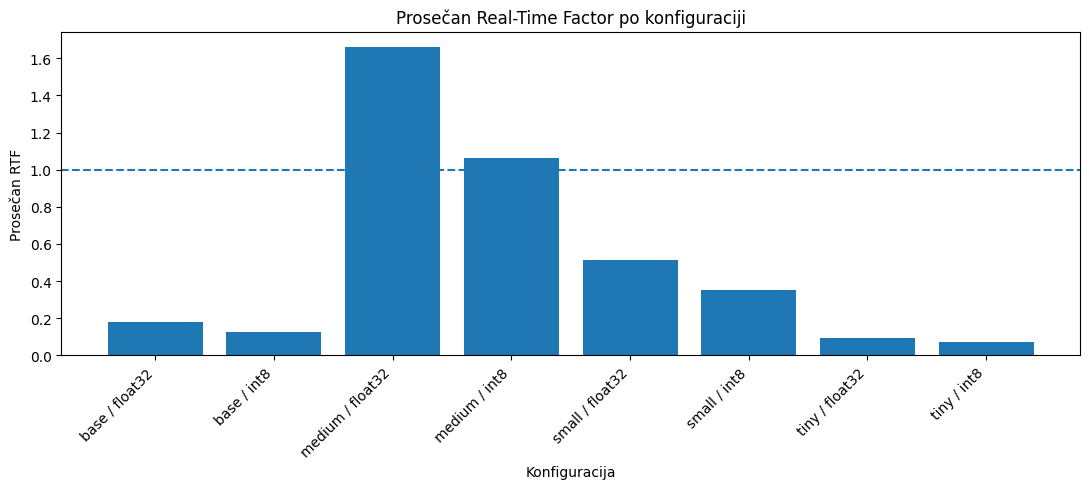

In [14]:
# ============================================================
# GRAFIK — PROSEČAN RTF
# ============================================================

grafik_rtf = tabela_prosek.copy()

grafik_rtf["Konfiguracija"] = (
    grafik_rtf["Model"] +
    " / " +
    grafik_rtf["Kvantizacija"]
)

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_rtf["Konfiguracija"],
    grafik_rtf["Prosecan_RTF"]
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Konfiguracija")
plt.ylabel("Prosečan RTF")
plt.title("Prosečan Real-Time Factor po konfiguraciji")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

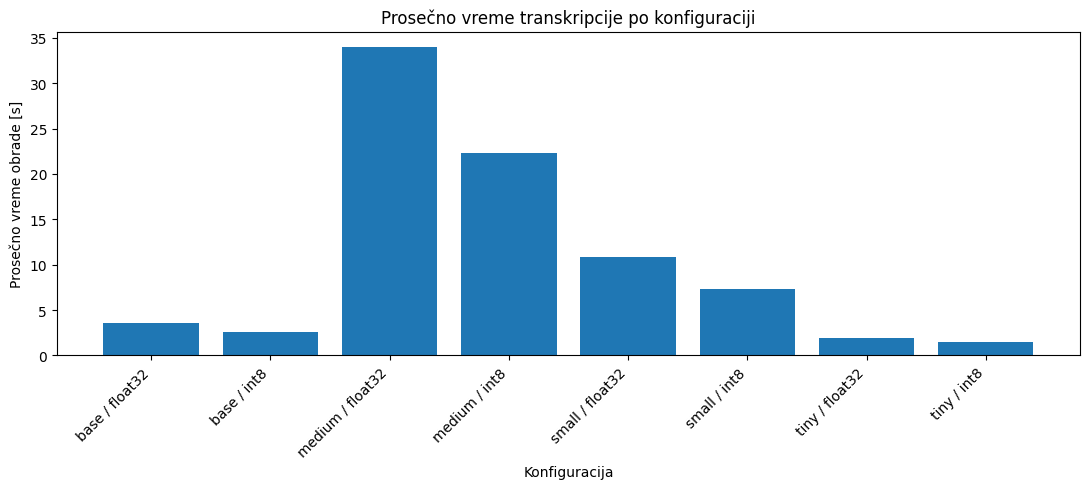

In [15]:
# ============================================================
# GRAFIK — PROSEČNO VREME OBRADE
# ============================================================

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_rtf["Konfiguracija"],
    grafik_rtf["Prosecno_vreme"]
)

plt.xlabel("Konfiguracija")
plt.ylabel("Prosečno vreme obrade [s]")
plt.title("Prosečno vreme transkripcije po konfiguraciji")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

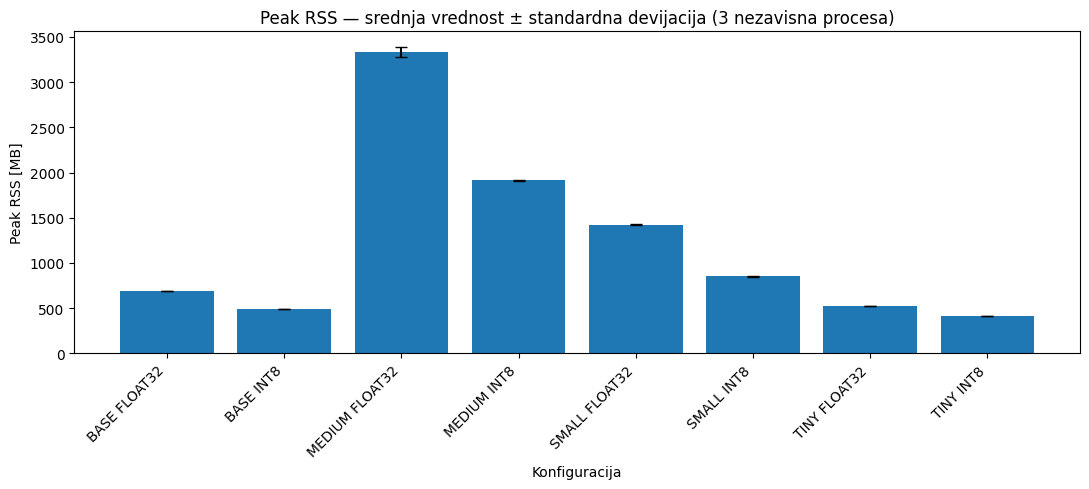

In [16]:
# ============================================================
# GRAFIK — PEAK RSS IZ NEZAVISNIH PROCESA
# ============================================================

grafik_ram = tabela_ram_rezime.copy()

grafik_ram["Konfiguracija"] = (
    grafik_ram["Model"].str.upper()
    + " "
    + grafik_ram["Kvantizacija"].str.upper()
)

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_ram["Konfiguracija"],
    grafik_ram["Peak_RSS_mean_MB"],
    yerr=grafik_ram["Peak_RSS_std_MB"],
    capsize=4
)

plt.xlabel("Konfiguracija")
plt.ylabel("Peak RSS [MB]")
plt.title("Peak RSS — srednja vrednost ± standardna devijacija (3 nezavisna procesa)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


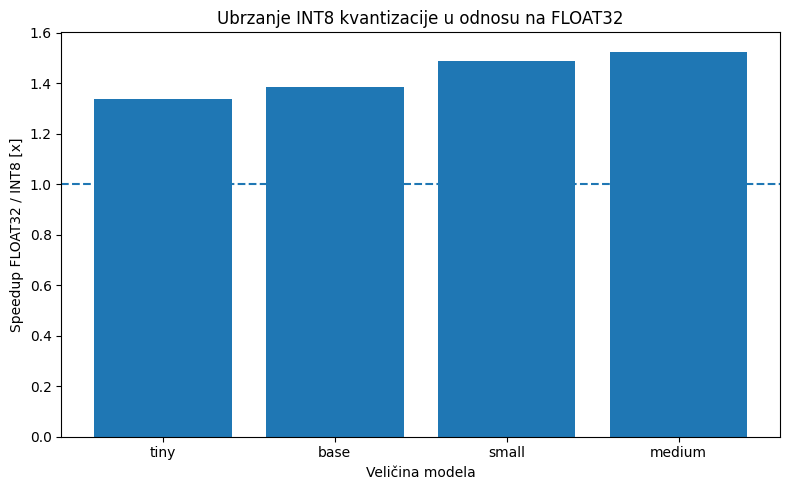

In [17]:
# ============================================================
# GRAFIK — INT8 SPEEDUP U ODNOSU NA FLOAT32
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    tabela_poredjenje["Model"],
    tabela_poredjenje["Speedup INT8 [x]"]
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Veličina modela")
plt.ylabel("Speedup FLOAT32 / INT8 [x]")
plt.title("Ubrzanje INT8 kvantizacije u odnosu na FLOAT32")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# AUTOMATSKI ZAVRŠNI REZIME
# ============================================================

najbrza = tabela_prosek.loc[
    tabela_prosek["Prosecno_vreme"].idxmin()
]

najmanji_rtf = tabela_prosek.loc[
    tabela_prosek["Prosecan_RTF"].idxmin()
]


print("=" * 100)
print("ZAVRŠNI REZIME — KVANTIZACIJA, LATENCIJA I RTF")
print("=" * 100)

print(f"Broj audio zapisa: {len(test_set)}")
print(f"Broj modela: {len(model_velicine)}")
print(f"Broj kvantizacija: {len(kvantizacije)}")
print(f"Broj uspešnih merenja: {len(tabela_rezultati)}")

print(
    f"\nNajbrža konfiguracija: "
    f"{najbrza['Model']} / {najbrza['Kvantizacija']}"
)
print(
    f"Prosečno vreme: {najbrza['Prosecno_vreme']:.3f} s"
)

print(
    f"Najmanji prosečan RTF: "
    f"{najmanji_rtf['Model']} / {najmanji_rtf['Kvantizacija']} "
    f"= {najmanji_rtf['Prosecan_RTF']:.4f}"
)


print("\nINT8 VS FLOAT32:")

for _, red in tabela_poredjenje.iterrows():
    print(
        f"{red['Model']:<7} | "
        f"speedup {red['Speedup INT8 [x]']:.2f}x | "
        f"smanjenje vremena {red['Smanjenje vremena INT8 [%]']:.2f}% | "
        f"RTF INT8 {red['INT8 RTF']:.3f} | "
        f"RTF F32 {red['FLOAT32 RTF']:.3f}"
    )

najmanji_ram = tabela_ram_rezime.loc[
    tabela_ram_rezime["Peak_RSS_mean_MB"].idxmin()
]

print(
    f"\nNajmanji prosečan peak RSS: "
    f"{najmanji_ram['Model']} / {najmanji_ram['Kvantizacija']} "
    f"= {najmanji_ram['Peak_RSS_mean_MB']:.2f} ± "
    f"{najmanji_ram['Peak_RSS_std_MB']:.2f} MB"
)

print(
    "\nRAM za konačno rangiranje potiče iz 3 nezavisna "
    "Python procesa po konfiguraciji."
)



ZAVRŠNI REZIME — KVANTIZACIJA, LATENCIJA I RTF
Broj audio zapisa: 40
Broj modela: 4
Broj kvantizacija: 2
Broj uspešnih merenja: 320

Najbrža konfiguracija: tiny / int8
Prosečno vreme: 1.453 s
Najmanji prosečan RTF: tiny / int8 = 0.0730

INT8 VS FLOAT32:
tiny    | speedup 1.34x | smanjenje vremena 25.30% | RTF INT8 0.073 | RTF F32 0.095
base    | speedup 1.38x | smanjenje vremena 27.67% | RTF INT8 0.127 | RTF F32 0.178
small   | speedup 1.49x | smanjenje vremena 32.69% | RTF INT8 0.351 | RTF F32 0.514
medium  | speedup 1.52x | smanjenje vremena 34.41% | RTF INT8 1.061 | RTF F32 1.659

Najmanji prosečan peak RSS: tiny / int8 = 416.30 ± 0.71 MB

RAM za konačno rangiranje potiče iz 3 nezavisna Python procesa po konfiguraciji.


In [19]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

tabela_rezultati.to_csv(
    REZULTATI_DIR / "05_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_prosek.to_csv(
    REZULTATI_DIR / "05_rezime_konfiguracije.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_model_load.to_csv(
    REZULTATI_DIR / "05_model_load_ram.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_duzine.to_csv(
    REZULTATI_DIR / "05_po_duzini.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_govornici.to_csv(
    REZULTATI_DIR / "05_po_govorniku.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_poredjenje.to_csv(
    REZULTATI_DIR / "05_int8_vs_float32.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_ram_ponavljanja.to_csv(
    REZULTATI_DIR / "05_ram_peak_rss_ponavljanja.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_ram_rezime.to_csv(
    REZULTATI_DIR / "05_ram_peak_rss_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\05_kvantizacija_latencija_rtf


## Zaključak eksperimenta

Eksperiment na 40 prirodnih srpskih audio zapisa pokazao je da INT8 kvantizacija može značajno poboljšati performanse Faster-Whisper modela pri CPU izvršavanju.

INT8 je bio brži od FLOAT32 za sve četiri testirane veličine modela. Ostvareno ubrzanje iznosilo je **1,22× za tiny**, **1,39× za base**, **1,21× za small** i **1,64× za medium**. Najveći efekat kvantizacije zato je zabeležen kod `medium` modela, gde je prosečno vreme smanjeno sa **28,991 s na 17,633 s**, odnosno za **39,18%**.

Posebno značajan rezultat predstavlja promena RTF-a kod `medium` modela. FLOAT32 konfiguracija imala je prosečan RTF od **1,390**, dok je INT8 smanjio ovu vrednost na **0,832**. Udeo snimaka obrađenih sa `RTF < 1` povećan je sa **25% na 80%**, što pokazuje da kvantizacija kod većeg modela može napraviti praktično značajnu razliku u mogućnosti obrade zvuka približno u realnom vremenu na CPU-u.

Najbrža testirana konfiguracija bila je `tiny INT8` sa prosečnim vremenom od **1,355 s** i RTF-om **0,069**, dok povećavanje veličine modela očekivano povećava računarski trošak.

Rezultati dodatnog peak RAM-a tokom transkripcije pokazuju manji i manje konzistentan efekat kvantizacije nego rezultati vremena izvršavanja. Najizraženija razlika ponovo je zabeležena kod `medium` modela, gde je prosečni dodatni peak RAM smanjen sa približno **416,8 MB na 350,0 MB**, odnosno oko **16%**. Zbog toga RAM rezultate treba posmatrati kao procesna RSS merenja, a ne kao preciznu izolovanu memoriju modela.

Ukupno posmatrano, rezultati pokazuju da je glavna korist INT8 kvantizacije u ovom eksperimentu **smanjenje latencije i RTF-a**, pri čemu korist postaje naročito izražena kod većeg `medium` modela.
